# 14 - Multimodal inventory and comparison across transport modes

Every earlier notebook in this project analyzed a single network: the trip-adjacency graph of the whole Israeli GTFS feed, with all transport modes merged together. That's a legitimate object - a rider doesn't care which kind of vehicle carries them - but it hides a fact that matters a lot for robustness: the feed is really six different networks sharing one country. A bus segment and a rail segment are both an "edge", yet their build cost is different, they fail in different ways, and their redundancy is completely different.

This notebook separates them. For each `route_type` in GTFS it builds that mode's own trip-adjacency graph, in a single streaming pass over `stop_times.txt`, and measures the same structural quantities for all of them side by side: nodes, edges, connected components, largest-component share, average degree, density, articulation points and bridges. It then compares the modes in one table and three figures, and explains why the differences are what they are.

**Research question.** How structurally different are Israel's transport modes when each is examined as a network in its own right, and what does that imply about where the fragility of the combined system actually lives?

This notebook is the frame for the block of mode-specific notebooks that follows it: notebook 15 (buses only), 16 (light rail and the minor modes) and 17 (multimodal transfer hubs) - all of them draw their scope from the inventory produced here.

## Input

| Path | Produced by | Used for |
|---|---|---|
| `outputs/nb/01_data_preparation/tables/routes_clean.csv` | Notebook 01 | `route_id -> route_type` |
| `outputs/nb/01_data_preparation/tables/trips_clean.csv` | Notebook 01 | `trip_id -> route_id` |
| `outputs/nb/01_data_preparation/tables/stops_clean.csv` | Notebook 01 | Stop names, coordinates, district / metropolitan area |
| `outputs/nb/02_graph_construction/tables/nodes.csv`, `edges.csv` | Notebook 02 | Optional cross-check only |
| `israel-public-transportation/stop_times.txt` | The raw feed | The segments themselves |

**Notebooks that must run first:** `01_data_preparation` (required). `02_graph_construction` is optional - it's used only for a reconciliation printout, and the notebook skips that check with a message if step 02 is missing.

**External data dependency.** `stop_times.txt` weighs 816 MB / about 15.7M rows and is not tracked in git. The download cell below pulls it from Google Drive on the first run. The file is read streaming, line by line, and is never loaded as a whole table.

## Output (everything under `outputs/nb/14_multimodal_inventory/`)

| Path | Contents |
|---|---|
| `tables/mode_inventory.csv` | `route_type, mode_label, routes, trips, stops, directed_edges` |
| `tables/mode_network_summary.csv` | `mode_label, nodes, edges, components, largest_component_share, avg_degree, articulation_points, bridges` |
| `tables/mode_structure_details.csv` | The same modes with density, median/max degree, and the shares of articulation points and bridges - the columns that didn't fit the required schema |
| `tables/edges_by_mode.csv` | `mode_label, from_stop, to_stop, trip_frequency` - the raw streaming result, so the mode notebooks that follow don't have to read 816 MB again |
| `tables/stop_mode_calls.csv` | `mode_label, stop_id, stop_calls` - scheduled stops at each station per mode |
| `tables/stop_modes.csv` | One row per stop: which modes serve it, how many, and the total number of stops (a convenient input for notebook 17, which owns the multimodal analysis) |
| `stream_stats.json`, `mode_comparison_summary.json` | The streaming counters and the headline numbers per mode |
| `figures/mode_size_comparison.png`, `figures/mode_structure_comparison.png`, `figures/mode_map.png` | The three figures |

Nothing outside this folder is written.

## 1. Environment setup

Identical to every other notebook in the series, so the whole set runs the same way locally and on Google Colab. `_ensure(...)` pip-installs only packages that are actually missing, `find_repo_root()` climbs upward from the working directory looking for the GTFS folder (and clones the repo if we're on Colab), and then the cell sets `REPO`, `DATA` and `OUT`. Everything below depends on those three paths, so this cell has to run first.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Repo root: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר


## 2. Libraries, stage folders, cost controls and the mode vocabulary

The scientific stack plus the standard-library `csv` module, which is what actually reads the 816 MB feed line by line. This stage owns exactly one folder, `outputs/nb/14_multimodal_inventory/`, with `tables/` and `figures/` inside it.

**Cost controls.** The only expensive operation in this notebook is the streaming pass over `stop_times.txt`: about 3-6 minutes depending on disk speed, since all ~15.7M rows have to be parsed. Because the result is deterministic, the pass writes its counters to `tables/edges_by_mode.csv` and `tables/stop_mode_calls.csv`, and a later run reloads them in about a second. Set `FORCE_RESTREAM = True` to ignore the cache and reread the feed. Everything else - building six graphs, articulation points and bridges - is linear-time DFS work and finishes in a few seconds even on the 26k-node bus graph. `MAP_MAX_POINTS_PER_MODE` caps how many points per mode are drawn in the geographic figure; rasterizing about 30k points at 150 dpi takes a few seconds.

**Mode labels.** The six `route_type` codes present in this feed are listed explicitly. The labels were copied verbatim from notebook 11 so the two notebooks agree with each other, and they're worded with deliberate care where the GTFS code is misleading: `8` is nominally "trolleybus" but in this feed it's used by shared-taxi operators, and `715` is the GTFS code for "on-demand bus service". Any unexpected code is labeled `other (<code>)` rather than silently dropped.

In [2]:
# --- Libraries, stage folders and cost knobs ------------------------------
_ensure('pandas', 'numpy', 'networkx', 'matplotlib', 'seaborn')

import csv, json, time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.05)

# A handful of rows in stop_times.txt are very long; raise the csv field limit up front.
csv.field_size_limit(10_000_000)

# --- Stage output folders -------------------------------------------------
STAGE = OUT / '14_multimodal_inventory'
TABLES = STAGE / 'tables'
FIGURES = STAGE / 'figures'
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# --- Cost knobs (see the markdown above) ---------------------------------
FORCE_RESTREAM = False           # True -> always re-read the 816 MB feed (3-6 minutes)
PROGRESS_EVERY = 2_000_000       # progress print interval during the streaming pass
FIG_DPI = 150                    # figure resolution; drop to 90 for smaller files
MAP_ALPHA = 0.45                 # point transparency on the geographic mode map
MAP_MAX_POINTS_PER_MODE = 40_000 # subsample cap per mode on the map
SEED = 42                        # fixes the map subsample

# --- GTFS mode vocabulary (labels match notebook 11) ----------------------
MODE_LABELS = {
    '0': 'tram/light rail',
    '2': 'rail',
    '3': 'bus',
    '5': 'cable tram',
    '8': 'trolleybus/taxi-coded',
    '715': 'demand/other bus',
}
UNKNOWN_MODE = 'unknown'

def mode_label(route_type):
    """Human-readable name for a GTFS route_type code; never raises, never drops."""
    code = str(route_type).strip()
    if code == '' or code.lower() == 'nan':
        return UNKNOWN_MODE
    return MODE_LABELS.get(code, f'other ({code})')

print('stage folder :', STAGE)
print('modes tracked:', ', '.join(MODE_LABELS.values()))

stage folder : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\14_multimodal_inventory
modes tracked: tram/light rail, rail, bus, cable tram, trolleybus/taxi-coded, demand/other bus


## 3. Rendering Hebrew labels

Station names in the Israeli feed are in Hebrew, and the tables printed below show them. Matplotlib doesn't implement the Unicode bidirectional algorithm, so right-to-left text is drawn reversed. The cell applies a one-time patch to `matplotlib.text.Text.set_text` so any string containing Hebrew is converted to display order with `python-bidi`, and picks a font that includes Hebrew glyphs. It's idempotent, so running it again doesn't stack extra patches. Because the patch is global, from here on Hebrew strings should be passed to matplotlib raw - an extra manual call to `fix_he()` would reverse the text twice.

In [3]:
# Stop names are Hebrew. Whether they render reversed depends on the matplotlib build:
# most builds do NOT apply the Unicode bidi algorithm (so Hebrew must be reordered with
# python-bidi), but libraqm/raqm builds (some Colab installs, newer wheels) apply bidi
# themselves. We detect what THIS matplotlib does and only reorder when it does not, so
# labels render correctly on every environment and are never double-reversed.
_ensure("python-bidi")
import re
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext
from bidi.algorithm import get_display

def _mpl_reorders_hebrew():
    """True if matplotlib already applies the bidi algorithm itself (so get_display must NOT be applied)."""
    try:
        from matplotlib.figure import Figure
        from matplotlib.backends.backend_agg import FigureCanvasAgg
        def _ink_cols(s):
            fig = Figure(figsize=(3, 1), dpi=100)
            FigureCanvasAgg(fig)
            ax = fig.add_axes([0, 0, 1, 1])
            ax.axis("off")
            ax.text(0.5, 0.5, s, fontsize=32, ha="center", va="center")
            fig.canvas.draw()
            prof = (np.asarray(fig.canvas.buffer_rgba())[:, :, :3].mean(2) < 128).sum(0).astype(float)
            nz = np.where(prof > 0)[0]
            return prof[nz.min():nz.max() + 1] if len(nz) else prof
        # Probe: Hebrew letters then digits. The digits are logically LAST, so in plain
        # logical order they render on the RIGHT; if matplotlib applies bidi they move LEFT.
        probe = _ink_cols("אבג12")
        tmpl = _ink_cols("12")
        n = len(tmpl)
        if n < 2 or len(probe) <= n:
            return False
        t = tmpl - tmpl.mean()
        best_c, best_off = -2.0, 0
        for off in range(len(probe) - n + 1):
            w = probe[off:off + n] - probe[off:off + n].mean()
            denom = ((w * w).sum() * (t * t).sum()) ** 0.5
            c = float((w * t).sum() / denom) if denom > 0 else 0.0
            if c > best_c:
                best_c, best_off = c, off
        return (best_off / (len(probe) - n)) < 0.5
    except Exception:
        return False

# Decide once, at import time, whether matplotlib already handles Hebrew.
_MPL_BIDI = _mpl_reorders_hebrew()

# Fail loudly only when we actually depend on python-bidi (matplotlib is NOT reordering).
# A broken or no-op build would make get_display a pass-through and render Hebrew reversed.
if not _MPL_BIDI and get_display("אבג") != "גבא":
    raise RuntimeError(
        "matplotlib does not reorder Hebrew and python-bidi is a no-op; Hebrew figure "
        "labels would render reversed. Reinstall a working build:\n"
        "    pip install -U --force-reinstall 'python-bidi>=0.6.7'"
    )

_HEBREW_RE = re.compile(r"[֐-׿]")

def fix_he(text):
    """Return display-ordered text. Left untouched for non-Hebrew, or when matplotlib already applies bidi."""
    if _MPL_BIDI or not isinstance(text, str) or not _HEBREW_RE.search(text):
        return text
    return get_display(text)

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    if getattr(mtext.Text, "_bidi_patched", False):
        return
    _orig = mtext.Text.set_text
    def set_text(self, s):
        if isinstance(s, str) and getattr(self, "_bidi_display", None) == s:
            return _orig(self, s)
        fixed = fix_he(s)
        if isinstance(fixed, str):
            self._bidi_display = fixed
        return _orig(self, fixed)
    mtext.Text.set_text = set_text
    mtext.Text._bidi_patched = True

install_hebrew()

## 4. Locating the cleaned GTFS tables from step 01

The three small tables this notebook needs come from `01_data_preparation`. Stage folders are located by their two-digit prefix rather than an exact slug, so a folder renamed from `01_data_preparation` to anything else starting with `01` is still found. If the folder or file is missing, the helper functions raise `FileNotFoundError` naming the notebook to run - a silent fall-back to a default here would produce a mode inventory where every trip is labeled `unknown`, which looks plausible but is completely wrong.

Everything is read as strings. GTFS IDs are opaque codes; letting pandas infer types would turn `route_type` into an integer, strip leading zeros from IDs, and break the joins below.

In [4]:
# --- Resolve earlier stages by their two-digit prefix ---------------------
def find_stage(prefix, notebook_hint):
    """Return an earlier stage's output folder, matched by its NN prefix."""
    matches = sorted(p for p in OUT.glob(f'{prefix}*') if p.is_dir())
    if not matches:
        raise FileNotFoundError(
            f'No stage folder starting with "{prefix}" under {OUT}. '
            f'Run notebook {notebook_hint} first.')
    return matches[0]


def stage_artifact(prefix, filename, notebook_hint):
    """Path of `filename` inside stage `prefix`, or a FileNotFoundError that says why."""
    stage = find_stage(prefix, notebook_hint)
    direct = stage / 'tables' / filename
    if direct.exists():
        return direct
    hits = sorted(stage.rglob(filename))
    if not hits:
        raise FileNotFoundError(
            f'{filename} not found under {stage}. '
            f'Run notebook {notebook_hint} first - it writes {filename}.')
    return hits[0]


def read_gtfs_table(path):
    """GTFS ids are opaque codes: read every column as a string, keep blanks as ''."""
    return pd.read_csv(path, dtype=str, keep_default_na=False, encoding='utf-8-sig')


routes = read_gtfs_table(stage_artifact('01', 'routes_clean.csv', '01_data_preparation'))
trips = read_gtfs_table(stage_artifact('01', 'trips_clean.csv', '01_data_preparation'))
stops = read_gtfs_table(stage_artifact('01', 'stops_clean.csv', '01_data_preparation'))

for name, frame, column in [('routes_clean', routes, 'route_type'),
                            ('trips_clean', trips, 'route_id'),
                            ('stops_clean', stops, 'stop_id')]:
    if column not in frame.columns:
        raise KeyError(f'{name}.csv has no "{column}" column - re-run 01_data_preparation.')

print(f'routes: {len(routes):,}   trips: {len(trips):,}   stops: {len(stops):,}')
print('route_type codes present:', sorted(set(routes['route_type'])))

routes: 7,792   trips: 420,133   stops: 34,932
route_type codes present: ['0', '2', '3', '5', '715', '8']


## 5. Scheduled routes and trips per mode, and the `trip_id -> mode` mapping

Mode lives in `routes.txt`, but the file we have to read streaming (`stop_times.txt`) only knows `trip_id`. The bridge is `trips.txt`, so we assemble the two lookups once, in memory, into a single `trip_id -> mode_label` dictionary (about 420k records - a few tens of MB, negligible against the 816 MB we're about to read). Every segment found during the streaming pass is routed to its mode with a single dictionary lookup.

The same join supplies the first half of the required `mode_inventory.csv`: how many route records and how many scheduled trips each mode contributes. Note that a "route record" in GTFS is a direction-variant of a line, not a line - hence 962 rail "routes" for a network of about 67 stations. Trips whose `route_id` doesn't appear in `routes_clean.csv` would silently become `unknown`, so we count them explicitly.

In [5]:
# --- route_id -> route_type -> mode label, then trip_id -> mode label -----
route_type_of = dict(zip(routes['route_id'], routes['route_type']))
trip_mode = {trip: mode_label(route_type_of.get(route, ''))
             for trip, route in zip(trips['trip_id'], trips['route_id'])}

orphan_trips = sum(1 for route in trips['route_id'] if route not in route_type_of)

# Route records and scheduled trips per mode, straight from the small GTFS tables.
trips_typed = trips.assign(route_type=trips['route_id'].map(route_type_of).fillna(''))
meta = pd.DataFrame({
    'routes': routes.groupby('route_type').size(),
    'trips': trips_typed.groupby('route_type').size(),
}).fillna(0).astype(int)
meta.index.name = 'route_type'
meta = meta.reset_index()
meta['mode_label'] = meta['route_type'].map(mode_label)
meta = meta.sort_values('trips', ascending=False).reset_index(drop=True)

print(f'trip_id -> mode entries: {len(trip_mode):,}')
print(f'trips whose route_id is missing from routes_clean.csv: {orphan_trips:,}')
meta

trip_id -> mode entries: 420,133


trips whose route_id is missing from routes_clean.csv: 0


,route_type,routes,trips,mode_label
0,3,6796,412544,bus
1,5,4,3006,cable tram
2,0,8,2890,tram/light rail
3,2,962,1188,rail
4,715,14,458,demand/other bus
5,8,8,47,trolleybus/taxi-coded


## 6. External data dependency: `stop_times.txt`

`stop_times.txt` weighs 816 MB - well over GitHub's file-size limit - so it isn't in the repo. The cell below downloads it from Google Drive on the first run and skips the download if the file already exists. This is the notebook's only external network dependency; everything else is in the repo or produced by notebook 01. The download takes a few minutes on a first Colab run.

In [6]:
# stop_times.txt is 816MB and is not tracked in git - fetch it on demand.
_ensure("gdown")
import gdown
STOP_TIMES = DATA / "stop_times.txt"
if not STOP_TIMES.exists():
    gdown.download(id="1V_yPAWXV6mGTFGrfiosah5LngcLZnviW",
                   output=str(STOP_TIMES), quiet=False)
print("stop_times.txt:", round(STOP_TIMES.stat().st_size / 1024**2, 1), "MB")

stop_times.txt: 778.3 MB


## 7. One streaming pass, one edge counter per mode

This is the expensive cell: 3-6 minutes for about 15.7M rows. The naive way to compare six modes would be six passes over the file (or one pass per mode, as notebook 11 does for rail alone). Instead we make one pass and route each segment to its mode's counter on the fly, which costs one extra dictionary lookup per trip and turns a half-hour job into a five-minute one.

The state kept per row is O(1); the total state kept is O(number of unique segments), about 52k records across all modes. For each mode we accumulate:

* `edge_counts[mode][(u, v)]` - the number of that mode's trips passing through segment `u -> v`;
* `stop_calls[mode][stop]` - that mode's scheduled stops at that station (the per-mode equivalent of `stop_use_count` in step 02);
* `trips_observed[mode]`, `rows_by_mode[mode]` - reporting counters.

**The ordering assumption.** Exactly as in notebook 02, the pass assumes `stop_times.txt` is sorted by `(trip_id, stop_sequence)`, so consecutive rows of the same trip are consecutive stops. Notebook 02 checked this assumption over the full file and found zero regressions in `stop_sequence` and zero interleaved trip blocks, so the assumption is reused here rather than checked again; for the same reason the mode lookup is done once per trip block. If that check ever failed, the edges built here would be wrong in the same way step 02's would.

Note that no time parsing happens here at all, so the GTFS trap of "hours >= 24" (`25:30:00` means 01:30 on the next service day) never comes up here - that's notebook 18's problem. Trips that don't appear in `trips_clean.csv` are counted under `unknown` rather than dropped.

**Caching.** The result is deterministic, so after the first run it's written to `tables/edges_by_mode.csv` and `tables/stop_mode_calls.csv` and reloaded from there in about a second. `FORCE_RESTREAM = True` bypasses the cache.

In [7]:
# --- One pass over stop_times.txt, routing every segment to its mode ------
EDGES_BY_MODE = TABLES / 'edges_by_mode.csv'
STOP_MODE_CALLS = TABLES / 'stop_mode_calls.csv'
STREAM_STATS = STAGE / 'stream_stats.json'


def stream_mode_edges(path, trip_mode, progress_every=PROGRESS_EVERY):
    """Build one segment-weight counter per transport mode in a single streaming pass.

    Assumes the feed is sorted by (trip_id, stop_sequence), verified in notebook 02.
    Memory is O(|E| + |V|), never O(rows).
    """
    edge_counts = defaultdict(Counter)   # mode -> Counter[(u, v)] = trips on that segment
    stop_calls = defaultdict(Counter)    # mode -> Counter[stop_id] = scheduled stop calls
    trips_observed = Counter()           # mode -> distinct trips met in the feed
    rows_by_mode = Counter()
    rows_read = 0
    self_loops = 0
    t0 = time.time()

    with open(path, encoding='utf-8-sig', newline='') as handle:
        reader = csv.reader(handle)
        header = next(reader)
        for field in ('trip_id', 'stop_id'):
            if field not in header:
                raise ValueError(f'stop_times.txt has no "{field}" column')
        i_trip, i_stop = header.index('trip_id'), header.index('stop_id')

        prev_trip, prev_stop, mode = None, None, UNKNOWN_MODE
        for row in reader:
            rows_read += 1
            trip, stop = row[i_trip], row[i_stop]

            if trip != prev_trip:
                # New trip block: resolve the mode once per trip, not once per row,
                # and reset the predecessor so no edge crosses a trip boundary.
                mode = trip_mode.get(trip, UNKNOWN_MODE)
                trips_observed[mode] += 1
                prev_stop = None

            rows_by_mode[mode] += 1
            stop_calls[mode][stop] += 1
            if prev_stop is not None:
                if prev_stop != stop:
                    edge_counts[mode][(prev_stop, stop)] += 1
                else:
                    self_loops += 1

            prev_trip, prev_stop = trip, stop
            if progress_every and rows_read % progress_every == 0:
                print(f'    {rows_read:,} rows | {time.time() - t0:,.0f}s')

    stats = {
        'rows_read': rows_read,
        'self_loop_rows_skipped': self_loops,
        'rows_by_mode': dict(rows_by_mode),
        'trips_observed': dict(trips_observed),
        'elapsed_seconds': round(time.time() - t0, 1),
    }
    return edge_counts, stop_calls, stats


cache_ready = all(p.exists() for p in (EDGES_BY_MODE, STOP_MODE_CALLS, STREAM_STATS))
if cache_ready and not FORCE_RESTREAM:
    print('Re-using the cached per-mode counters from an earlier run of this notebook.')
    _cached_edges = pd.read_csv(EDGES_BY_MODE, dtype=str, keep_default_na=False,
                                encoding='utf-8-sig')
    edge_counts = defaultdict(Counter)
    for m, u, v, w in zip(_cached_edges['mode_label'], _cached_edges['from_stop'],
                          _cached_edges['to_stop'], _cached_edges['trip_frequency']):
        edge_counts[m][(u, v)] = int(w)
    _cached_calls = pd.read_csv(STOP_MODE_CALLS, dtype=str, keep_default_na=False,
                                encoding='utf-8-sig')
    stop_calls = defaultdict(Counter)
    for m, s, c in zip(_cached_calls['mode_label'], _cached_calls['stop_id'],
                       _cached_calls['stop_calls']):
        stop_calls[m][s] = int(c)
    with open(STREAM_STATS, encoding='utf-8') as handle:
        stream_stats = json.load(handle)
else:
    print('Streaming stop_times.txt (~15.7M rows) - this takes a few minutes ...')
    edge_counts, stop_calls, stream_stats = stream_mode_edges(STOP_TIMES, trip_mode)

print('rows read       : {:,}'.format(stream_stats['rows_read']))
print('self-loop rows  : {:,}'.format(stream_stats['self_loop_rows_skipped']))
print('elapsed seconds :', stream_stats['elapsed_seconds'])
print()
print('{:<24}{:>16}{:>10}{:>9}{:>11}'.format('mode', 'stop-time rows', 'trips',
                                             'stops', 'segments'))
for m, n_rows in sorted(stream_stats['rows_by_mode'].items(), key=lambda kv: -kv[1]):
    print('{:<24}{:>16,}{:>10,}{:>9,}{:>11,}'.format(
        m, n_rows, stream_stats['trips_observed'].get(m, 0),
        len(stop_calls.get(m, {})), len(edge_counts.get(m, {}))))

Streaming stop_times.txt (~15.7M rows) - this takes a few minutes ...


    2,000,000 rows | 2s


    4,000,000 rows | 3s


    6,000,000 rows | 5s


    8,000,000 rows | 6s


    10,000,000 rows | 8s


    12,000,000 rows | 10s


    14,000,000 rows | 11s


rows read       : 15,711,624
self-loop rows  : 718
elapsed seconds : 12.5

mode                      stop-time rows     trips    stops   segments
bus                           15,608,376   412,544   30,170     51,503
tram/light rail                   70,333     2,890      138        134
rail                              14,601     1,188       67        197
cable tram                        10,830     3,006        9         14
demand/other bus                   7,390       458      153        197
trolleybus/taxi-coded                 94        47       10          6


## 8. Saving the streaming result

Two long-format tables are written immediately, before any analysis, for two reasons: they're the cache that makes rerunning this notebook cheap, and they're the hand-off to the mode-specific notebooks that follow (15 bus, 16 light rail and minor modes, 17 multimodal hubs) so none of them has to touch the 816 MB feed again.

* `tables/edges_by_mode.csv` - `mode_label, from_stop, to_stop, trip_frequency`, one row per (mode, directed segment).
* `tables/stop_mode_calls.csv` - `mode_label, stop_id, stop_calls`, one row per (mode, station).
* `stream_stats.json` - the row / trip counters, so the numbers reported have a machine-readable source.

All CSVs are written as UTF-8 with BOM so Hebrew opens correctly in Excel.

In [8]:
# --- Persist the streaming result (also serves as the cache) --------------
edges_by_mode = pd.DataFrame(
    [{'mode_label': m, 'from_stop': u, 'to_stop': v, 'trip_frequency': int(w)}
     for m, counter in edge_counts.items() for (u, v), w in counter.items()]
)
edges_by_mode.to_csv(EDGES_BY_MODE, index=False, encoding='utf-8-sig')

stop_mode_calls = pd.DataFrame(
    [{'mode_label': m, 'stop_id': s, 'stop_calls': int(c)}
     for m, counter in stop_calls.items() for s, c in counter.items()]
)
stop_mode_calls.to_csv(STOP_MODE_CALLS, index=False, encoding='utf-8-sig')

with open(STREAM_STATS, 'w', encoding='utf-8') as handle:
    json.dump(stream_stats, handle, ensure_ascii=False, indent=2)

print(f'{len(edges_by_mode):,} (mode, segment) rows -> {EDGES_BY_MODE}')
print(f'{len(stop_mode_calls):,} (mode, stop) rows    -> {STOP_MODE_CALLS}')
print(f'streaming counters                  -> {STREAM_STATS}')
edges_by_mode.head()

52,051 (mode, segment) rows -> C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\14_multimodal_inventory\tables\edges_by_mode.csv
30,547 (mode, stop) rows    -> C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\14_multimodal_inventory\tables\stop_mode_calls.csv
streaming counters                  -> C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\14_multimodal_inventory\stream_stats.json


,mode_label,from_stop,to_stop,trip_frequency
0,bus,38725,15582,112
1,bus,15582,15583,216
2,bus,15583,16086,152
3,bus,16086,16085,186
4,bus,16085,16084,152


## 9. One graph per mode, measured the same way

Each mode now gets its own trip-adjacency graph, built to exactly the definition used for the full network in notebook 02: node = a station served by that mode, directed edge `u -> v` = some trip of that mode stops at `v` immediately after `u`, weight = the number of such trips. The undirected projection sums the weights of both directions, because a closed station or a blocked segment stops traffic in both directions.

For each mode we then compute, all in linear-time routines:

* **Size** - nodes, undirected edges, directed edges;
* **Sparsity** - density `2m / (n(n-1))`, average / median / max degree;
* **Fragmentation** - the number of connected components and the share of stations in the largest one;
* **Cut structure** - articulation points (nodes whose removal disconnects the graph) and bridges (edges with the same property), plus each as a share of the nodes / edges, which is the only fair way to compare a 26,000-node bus network to a 67-station rail network.

Modes that appear in `routes_clean.csv` but produced not even one segment still get a row of zeros instead of vanishing from the comparison. The whole cell runs in a few seconds; the bus graph dominates the runtime.

In [9]:
# --- Build and measure one network per mode ------------------------------
def build_mode_graphs(counter):
    """Directed trip-adjacency graph for one mode, plus its summed undirected view."""
    D = nx.DiGraph()
    for (u, v), w in counter.items():
        D.add_edge(u, v, weight=int(w))
    G = nx.Graph()
    for u, v, data in D.edges(data=True):
        if G.has_edge(u, v):
            G[u][v]['weight'] += data['weight']
        else:
            G.add_edge(u, v, weight=data['weight'])
    return G, D


def summarise_mode(label, G, D):
    """Size, sparsity, fragmentation and cut structure of a single mode's network."""
    n = G.number_of_nodes()
    m = G.number_of_edges()
    sizes = sorted((len(c) for c in nx.connected_components(G)), reverse=True)
    degrees = np.array([d for _, d in G.degree()]) if n else np.array([0])
    articulation = sorted(set(nx.articulation_points(G))) if n else []
    bridges = list(nx.bridges(G)) if n else []
    return {
        'mode_label': label,
        'nodes': n,
        'edges': m,
        'directed_edges': D.number_of_edges(),
        'components': len(sizes),
        'largest_component_nodes': sizes[0] if sizes else 0,
        'largest_component_share': round(sizes[0] / n, 4) if n else 0.0,
        'avg_degree': round(float(degrees.mean()), 2) if n else 0.0,
        'median_degree': float(np.median(degrees)) if n else 0.0,
        'max_degree': int(degrees.max()) if n else 0,
        'density': round(nx.density(G), 6) if n > 1 else 0.0,
        'articulation_points': len(articulation),
        'bridges': len(bridges),
        'articulation_share': round(len(articulation) / n, 4) if n else 0.0,
        'bridge_share': round(len(bridges) / m, 4) if m else 0.0,
    }


observed_modes = sorted(edge_counts, key=lambda m: -len(edge_counts[m]))
declared_only = [m for m in meta['mode_label'] if m not in observed_modes]

mode_graphs = {}
rows = []
for label in observed_modes + declared_only:
    t0 = time.time()
    G_mode, D_mode = build_mode_graphs(edge_counts.get(label, Counter()))
    mode_graphs[label] = (G_mode, D_mode)
    rows.append(summarise_mode(label, G_mode, D_mode))
    print('{:<24}{:>8,} nodes{:>9,} edges   ({:.1f}s)'.format(
        label, G_mode.number_of_nodes(), G_mode.number_of_edges(), time.time() - t0))

structure = pd.DataFrame(rows).sort_values('nodes', ascending=False).reset_index(drop=True)
structure

bus                       30,169 nodes   51,387 edges   (0.6s)
rail                          67 nodes       99 edges   (0.0s)
demand/other bus             153 nodes      194 edges   (0.0s)
tram/light rail              138 nodes      134 edges   (0.0s)
cable tram                     9 nodes        7 edges   (0.0s)
trolleybus/taxi-coded          8 nodes        5 edges   (0.0s)


,mode_label,nodes,edges,directed_edges,components,largest_component_nodes,largest_component_share,avg_degree,median_degree,max_degree,density,articulation_points,bridges,articulation_share,bridge_share
0,bus,30169,51387,51503,2,30165,0.9999,3.41,3.0,62,0.000113,754,812,0.0250,0.0158
1,demand/other bus,153,194,197,2,129,0.8431,2.54,2.0,6,0.016684,21,12,0.1373,0.0619
2,tram/light rail,138,134,134,4,35,0.2536,1.94,2.0,3,0.014175,128,134,0.9275,1.0000
3,rail,67,99,197,1,67,1.0000,2.96,2.0,8,0.044776,14,11,0.2090,0.1111
4,cable tram,9,7,14,2,6,0.6667,1.56,2.0,2,0.194444,5,7,0.5556,1.0000
5,trolleybus/taxi-coded,8,5,6,3,4,0.5000,1.25,1.0,3,0.178571,1,5,0.1250,1.0000


## 10. `tables/mode_inventory.csv`

The first required output: one row per mode with the four headline volumes - `routes` and `trips` from the GTFS metadata, `stops` and `directed_edges` as observed in the feed itself. The two halves answer different questions. `routes` and `trips` say how much service a mode runs; `stops` and `directed_edges` say how much network it covers. Rail and light rail are the clearest illustration: light rail runs more than twice the trips of heavy rail over a network a full order of magnitude smaller.

`trips` is the number of scheduled trip records in `trips.txt`, not trips per day - the feed is a snapshot of one schedule window, and a single trip record is one scheduled run. Any mode that appears in `stop_times.txt` but not in `routes_clean.csv` (that is, `unknown`) is included as an explicit row rather than dropped, so the table always accounts for every stop-time row.

In [10]:
# --- tables/mode_inventory.csv -------------------------------------------
observed_stops = {m: len(c) for m, c in stop_calls.items()}
observed_edges = {m: len(c) for m, c in edge_counts.items()}

inventory = meta.copy()
inventory['stops'] = inventory['mode_label'].map(observed_stops).fillna(0).astype(int)
inventory['directed_edges'] = (inventory['mode_label'].map(observed_edges)
                               .fillna(0).astype(int))

# Modes seen while streaming but absent from routes_clean.csv are added, not dropped.
extra_modes = [m for m in observed_stops if m not in set(inventory['mode_label'])]
if extra_modes:
    print('Modes present in stop_times.txt but not in routes_clean.csv:', extra_modes)
    inventory = pd.concat([inventory, pd.DataFrame([
        {'route_type': '', 'mode_label': m, 'routes': 0, 'trips': 0,
         'stops': observed_stops[m], 'directed_edges': observed_edges.get(m, 0)}
        for m in extra_modes])], ignore_index=True)

mode_inventory = (inventory[['route_type', 'mode_label', 'routes', 'trips',
                             'stops', 'directed_edges']]
                  .sort_values('trips', ascending=False)
                  .reset_index(drop=True))
mode_inventory.to_csv(TABLES / 'mode_inventory.csv', index=False, encoding='utf-8-sig')

print('saved:', TABLES / 'mode_inventory.csv')
mode_inventory

saved: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\14_multimodal_inventory\tables\mode_inventory.csv


,route_type,mode_label,routes,trips,stops,directed_edges
0,3,bus,6796,412544,30170,51503
1,5,cable tram,4,3006,9,14
2,0,tram/light rail,8,2890,138,134
3,2,rail,962,1188,67,197
4,715,demand/other bus,14,458,153,197
5,8,trolleybus/taxi-coded,8,47,10,6


## 11. `tables/mode_network_summary.csv` and the extended detail table

The second required output holds the structural comparison in exactly the schema the downstream notebooks expect: `mode_label, nodes, edges, components, largest_component_share, avg_degree, articulation_points, bridges`. To keep that contract clean, the extra quantities measured above - density, median and max degree, the directed-edge count, the size of the largest component, and the articulation-point / bridge shares that make small and large modes comparable - move to a companion table, `tables/mode_structure_details.csv`, together with the route and trip volumes, so a single file supports the whole discussion.

`mode_comparison_summary.json` carries the same numbers in nested form for the report.

In [11]:
# --- tables/mode_network_summary.csv (exact required schema) -------------
mode_network_summary = structure[[
    'mode_label', 'nodes', 'edges', 'components', 'largest_component_share',
    'avg_degree', 'articulation_points', 'bridges']].copy()
mode_network_summary.to_csv(TABLES / 'mode_network_summary.csv',
                            index=False, encoding='utf-8-sig')

# --- tables/mode_structure_details.csv (everything else we measured) -----
details = structure.merge(
    mode_inventory[['mode_label', 'route_type', 'routes', 'trips']],
    on='mode_label', how='left')
details['routes'] = details['routes'].fillna(0).astype(int)
details['trips'] = details['trips'].fillna(0).astype(int)
details['route_type'] = details['route_type'].fillna('')
details['observed_trips'] = (details['mode_label']
                             .map(stream_stats['trips_observed']).fillna(0).astype(int))
details['stop_time_rows'] = (details['mode_label']
                             .map(stream_stats['rows_by_mode']).fillna(0).astype(int))
details['trips_per_edge'] = np.where(
    details['edges'] > 0,
    (details['observed_trips'] / details['edges'].replace(0, np.nan)).round(2), 0.0)
details = details[[
    'route_type', 'mode_label', 'routes', 'trips', 'observed_trips', 'stop_time_rows',
    'nodes', 'edges', 'directed_edges', 'density', 'avg_degree', 'median_degree',
    'max_degree', 'components', 'largest_component_nodes', 'largest_component_share',
    'articulation_points', 'articulation_share', 'bridges', 'bridge_share',
    'trips_per_edge']]
details.to_csv(TABLES / 'mode_structure_details.csv', index=False, encoding='utf-8-sig')

# --- mode_comparison_summary.json ---------------------------------------
comparison_summary = {
    'modes': int(len(structure)),
    'total_stop_time_rows': int(stream_stats['rows_read']),
    'total_directed_segments_all_modes': int(structure['directed_edges'].sum()),
    'per_mode': {row['mode_label']: {key: row[key] for key in (
        'nodes', 'edges', 'directed_edges', 'components', 'largest_component_share',
        'avg_degree', 'density', 'articulation_points', 'articulation_share',
        'bridges', 'bridge_share')} for _, row in structure.iterrows()},
}
with open(STAGE / 'mode_comparison_summary.json', 'w', encoding='utf-8') as handle:
    json.dump(comparison_summary, handle, ensure_ascii=False, indent=2, default=float)

print('saved:', TABLES / 'mode_network_summary.csv')
print('saved:', TABLES / 'mode_structure_details.csv')
print('saved:', STAGE / 'mode_comparison_summary.json')
details

saved: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\14_multimodal_inventory\tables\mode_network_summary.csv
saved: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\14_multimodal_inventory\tables\mode_structure_details.csv
saved: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\14_multimodal_inventory\mode_comparison_summary.json


,route_type,mode_label,routes,trips,observed_trips,stop_time_rows,nodes,edges,directed_edges,density,...,median_degree,max_degree,components,largest_component_nodes,largest_component_share,articulation_points,articulation_share,bridges,bridge_share,trips_per_edge
0,3,bus,6796,412544,412544,15608376,30169,51387,51503,0.000113,...,3.0,62,2,30165,0.9999,754,0.0250,812,0.0158,8.03
1,715,demand/other bus,14,458,458,7390,153,194,197,0.016684,...,2.0,6,2,129,0.8431,21,0.1373,12,0.0619,2.36
2,0,tram/light rail,8,2890,2890,70333,138,134,134,0.014175,...,2.0,3,4,35,0.2536,128,0.9275,134,1.0000,21.57
3,2,rail,962,1188,1188,14601,67,99,197,0.044776,...,2.0,8,1,67,1.0000,14,0.2090,11,0.1111,12.00
4,5,cable tram,4,3006,3006,10830,9,7,14,0.194444,...,2.0,2,2,6,0.6667,5,0.5556,7,1.0000,429.43
5,8,trolleybus/taxi-coded,8,47,47,94,8,5,6,0.178571,...,1.0,3,3,4,0.5000,1,0.1250,5,1.0000,9.40


## 12. Cross-check: do the modes add up to the full-network graph?

A split like this is easy to get subtly wrong - a bad join would silently send half the bus trips to `unknown` and all the numbers above would still look plausible. So we reconcile against notebook 02, which built the same graph with no split by mode:

* The union of the per-mode station sets should match step 02's active stations (step 02's `nodes.csv` is slightly smaller because a station with no predecessor and no successor isn't a node there, while it does appear in our station-stop counters);
* The union of the per-mode segment sets should match step 02's directed-edge count almost exactly - the two should be identical, because both count unique `(from_stop, to_stop)` pairs over the same file;
* The sum across modes of the station counts is larger than that union, and the gap is exactly the multimodal stations that notebook 17 goes on to study. The same is true for segments served by more than one mode.

The check is optional: if step 02 wasn't run, the cell prints why it's skipping instead of failing.

In [12]:
# --- Reconcile the per-mode split against the whole-network graph --------
union_stops = set().union(*(set(c) for c in stop_calls.values())) if stop_calls else set()
union_edges = set().union(*(set(c) for c in edge_counts.values())) if edge_counts else set()
sum_stops = sum(len(c) for c in stop_calls.values())
sum_edges = sum(len(c) for c in edge_counts.values())

print(f'union of per-mode stops    : {len(union_stops):,}')
print(f'sum  of per-mode stops     : {sum_stops:,}   (a stop counted once per mode)')
print(f'union of per-mode segments : {len(union_edges):,}')
print(f'sum  of per-mode segments  : {sum_edges:,}')
print(f'multimodal surplus (stops) : {sum_stops - len(union_stops):,} extra (mode, stop) pairs')

try:
    nodes_all = pd.read_csv(stage_artifact('02', 'nodes.csv', '02_graph_construction'),
                            dtype=str, keep_default_na=False, encoding='utf-8-sig')
    edges_all = pd.read_csv(stage_artifact('02', 'edges.csv', '02_graph_construction'),
                            dtype=str, keep_default_na=False, encoding='utf-8-sig')
    print()
    print(f'stage 02 nodes.csv rows    : {len(nodes_all):,}')
    print(f'stage 02 edges.csv rows    : {len(edges_all):,}  (directed)')
    print(f'segment difference         : {len(union_edges) - len(edges_all):+,}')
except FileNotFoundError as err:
    print()
    print('Skipping the stage-02 cross-check:', err)

union of per-mode stops    : 30,466
sum  of per-mode stops     : 30,547   (a stop counted once per mode)
union of per-mode segments : 51,999
sum  of per-mode segments  : 52,051
multimodal surplus (stops) : 81 extra (mode, stop) pairs

stage 02 nodes.csv rows    : 30,463
stage 02 edges.csv rows    : 51,999  (directed)
segment difference         : +0


## 13. A stop-level view: which modes serve each station

The long `stop_mode_calls` table is pivoted to one row per station and joined to names and coordinates from `stops_clean.csv`. This is the source the map below is drawn from, and it's written to `tables/stop_modes.csv` as a convenient input for notebook 17 - notebook 17 owns the multimodal hub analysis (`transfer_hubs.csv`, its own schema and thresholds); this table is just the raw fact of "which modes touch this station", computed here because the streaming pass is where it's cheap to get.

`modes_served` is a `|`-separated, alphabetically sorted list, so it's stable and diff-friendly. Stations that appear in the feed but are missing from `stops_clean.csv` (dropped during cleaning, for example due to invalid coordinates) keep their row with empty attributes, and their count is reported rather than hidden.

In [13]:
# --- One row per stop: which modes serve it ------------------------------
geo = stops[['stop_id', 'stop_name', 'stop_lat', 'stop_lon']].copy()
geo['lat'] = pd.to_numeric(geo['stop_lat'], errors='coerce')
geo['lon'] = pd.to_numeric(geo['stop_lon'], errors='coerce')
for column in ('region', 'metro'):
    geo[column] = stops[column] if column in stops.columns else ''
geo = geo[['stop_id', 'stop_name', 'lat', 'lon', 'region', 'metro']]

stop_mode_geo = stop_mode_calls.merge(geo, on='stop_id', how='left')
missing_attrs = int(stop_mode_geo['stop_name'].isna().sum())
missing_coords = int(stop_mode_geo['lat'].isna().sum())

stop_modes = (stop_mode_geo
              .groupby('stop_id', as_index=False)
              .agg(stop_name=('stop_name', 'first'),
                   lat=('lat', 'first'),
                   lon=('lon', 'first'),
                   region=('region', 'first'),
                   metro=('metro', 'first'),
                   n_modes=('mode_label', 'nunique'),
                   modes_served=('mode_label', lambda s: '|'.join(sorted(set(s)))),
                   stop_calls=('stop_calls', 'sum')))
stop_modes = stop_modes.sort_values(['n_modes', 'stop_calls'], ascending=False)
stop_modes.to_csv(TABLES / 'stop_modes.csv', index=False, encoding='utf-8-sig')

print(f'stops in the feed                  : {len(stop_modes):,}')
print(f'  serving more than one mode       : {int((stop_modes["n_modes"] > 1).sum()):,}')
print(f'  (mode, stop) rows with no name   : {missing_attrs:,}')
print(f'  (mode, stop) rows with no coords : {missing_coords:,}')
print('saved:', TABLES / 'stop_modes.csv')
stop_modes.head(10)

stops in the feed                  : 30,466
  serving more than one mode       : 81
  (mode, stop) rows with no name   : 0
  (mode, stop) rows with no coords : 0
saved: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\14_multimodal_inventory\tables\stop_modes.csv


,stop_id,stop_name,lat,lon,region,metro,n_modes,modes_served,stop_calls
826,11080,מחלף הרטוב,31.767298,34.997537,Jerusalem,Periphery,2,bus|demand/other bus,2066
827,11081,מחלף הרטוב,31.767124,34.997730,Jerusalem,Periphery,2,bus|demand/other bus,1982
780,11028,שדרות יגאל אלון/קניון שער העיר,31.756197,34.985749,Jerusalem,Periphery,2,bus|demand/other bus,1403
17035,37273,שדרות יגאל אלון/הצבע,31.753943,34.994399,Jerusalem,Periphery,2,bus|demand/other bus,1275
20293,41660,כביש 38/דולמיט,31.760419,34.987449,Jerusalem,Periphery,2,bus|demand/other bus,1241
786,11035,יגאל אלון/העלייה,31.755910,34.989729,Jerusalem,Periphery,2,bus|demand/other bus,1198
17036,37274,שדרות יגאל אלון/הצבע,31.753714,34.994922,Jerusalem,Periphery,2,bus|demand/other bus,1146
1010,11288,שד.יגאל אלון/הבנאי,31.754837,34.992821,Jerusalem,Periphery,2,bus|demand/other bus,1010
863,11119,מחלף מסילת ציון,31.798378,35.014456,Jerusalem,Jerusalem,2,bus|demand/other bus,968
16760,36797,כביש 3855/שדרות יגאל אלון,31.751453,35.000784,Jerusalem,Periphery,2,bus|demand/other bus,956


## 14. Figure 1 - how big is each mode?

A grouped bar chart of the three size measures per mode: stations served, undirected segments, and scheduled trips. The y-axis is logarithmic, and that isn't a cosmetic choice: the bus is three to four orders of magnitude larger than the smallest modes on every axis, so on a linear scale five of the six bars would be invisible. The log scale is what makes the comparison readable, and it's also the straight way to present the claim: these aren't six comparable networks, but one nationwide network plus five small, specialized ones.

Note the crossovers. For the bus, both trips and stations are enormous. For cable tram and light rail, the trips bar towers over the stations and segments bars - a lot of service concentrated on a tiny network. That ratio is quantified as `trips_per_edge` in the detail table.

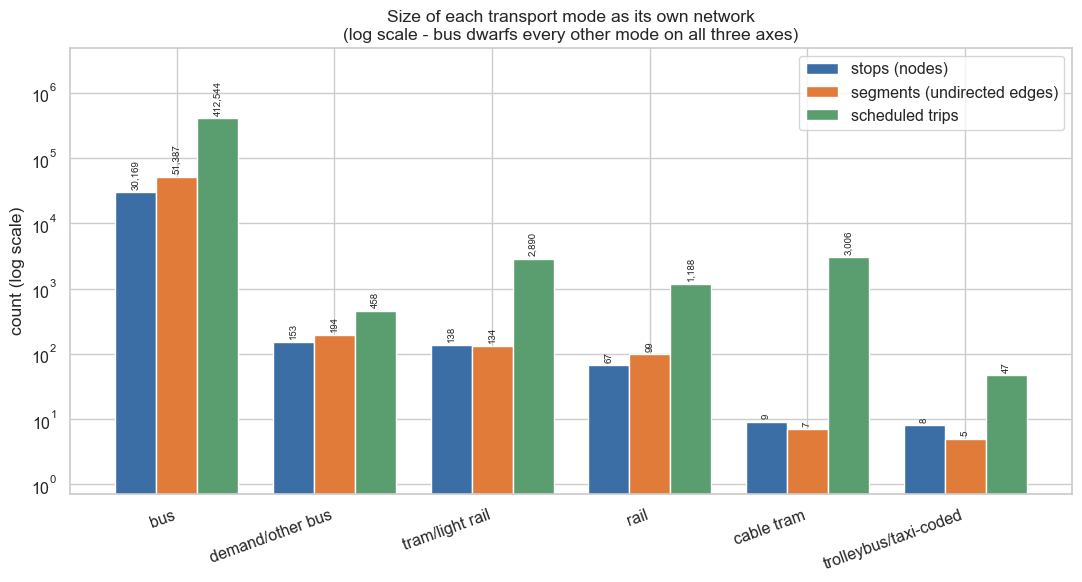

saved: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\14_multimodal_inventory\figures\mode_size_comparison.png


In [14]:
# --- Figure 1: grouped bar chart of size metrics per mode ----------------
plot_df = (mode_network_summary
           .merge(mode_inventory[['mode_label', 'trips']], on='mode_label', how='left')
           .fillna({'trips': 0})
           .sort_values('nodes', ascending=False)
           .reset_index(drop=True))

metrics = [('stops (nodes)', 'nodes'),
           ('segments (undirected edges)', 'edges'),
           ('scheduled trips', 'trips')]
x = np.arange(len(plot_df))
width = 0.26
colors = ['#3b6ea5', '#e07b39', '#5a9e6f']
ceiling = float(plot_df[['nodes', 'edges', 'trips']].to_numpy().max())

fig, ax = plt.subplots(figsize=(11, 6))
for k, (label, column) in enumerate(metrics):
    values = [max(int(v), 0) for v in plot_df[column]]
    bars = ax.bar(x + (k - 1) * width, values, width, label=label, color=colors[k])
    ax.bar_label(bars, labels=[f'{v:,}' for v in values],
                 fontsize=7, padding=2, rotation=90)

ax.set_yscale('log')
ax.set_ylim(0.7, ceiling * 12 if ceiling > 0 else 10)
ax.set_xticks(x)
ax.set_xticklabels(plot_df['mode_label'], rotation=20, ha='right')
ax.set_ylabel('count (log scale)')
ax.set_title('Size of each transport mode as its own network\n'
             '(log scale - bus dwarfs every other mode on all three axes)')
ax.legend(loc='upper right', frameon=True)
fig.tight_layout()
fig.savefig(FIGURES / 'mode_size_comparison.png', dpi=FIG_DPI)
plt.show()

print('saved:', FIGURES / 'mode_size_comparison.png')

## 15. Figure 2 - how fragile is each mode?

Absolute counts of articulation points aren't comparable across modes: the bus has thousands of them simply because it has tens of thousands of nodes. The three panels below therefore use normalized quantities:

1. **Average degree** - how many neighboring stations the typical station connects to. A value near 2 means the mode is essentially a collection of paths; above 3 means real meshing.
2. **Articulation-point share** - the fraction of that mode's stations whose closure would split its network. This is the most direct fragility number in this notebook.
3. **Largest-component share** - how much of the mode forms one connected system rather than disconnected islands.

Read them together: a mode can look robust on one and terrible on another. A mode made up of many separate two-station shuttles will show a low articulation-point share (nothing to cut) and a poor largest-component share.

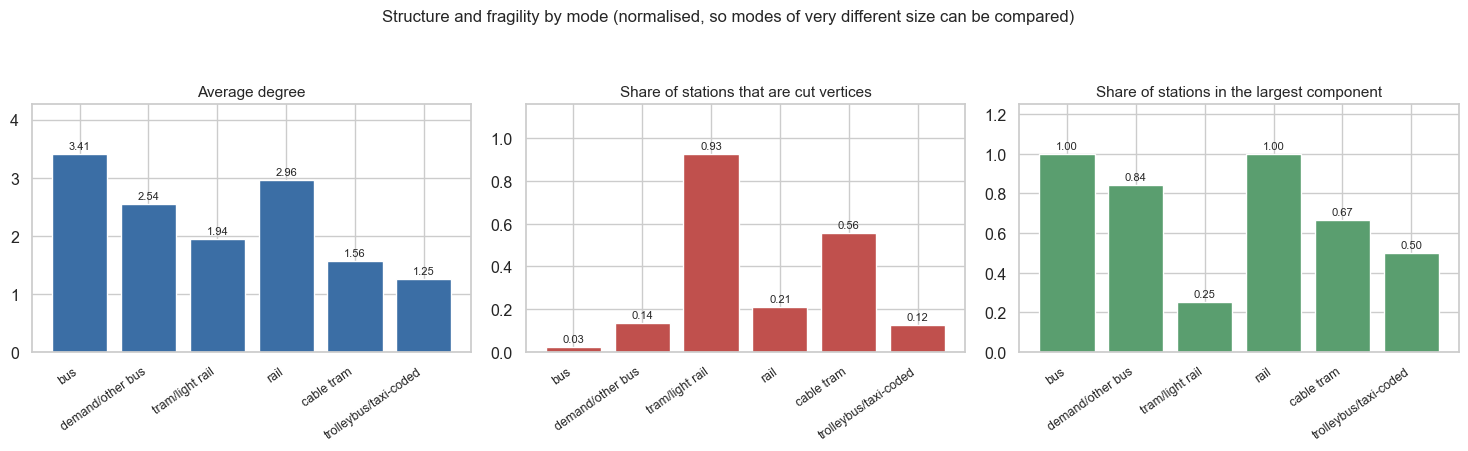

saved: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\14_multimodal_inventory\figures\mode_structure_comparison.png


In [15]:
# --- Figure 2: normalised structure / fragility per mode -----------------
frag = details.sort_values('nodes', ascending=False).reset_index(drop=True)
panels = [('avg_degree', 'Average degree', '#3b6ea5'),
          ('articulation_share', 'Share of stations that are cut vertices', '#c0504d'),
          ('largest_component_share', 'Share of stations in the largest component',
           '#5a9e6f')]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (column, title, color) in zip(axes, panels):
    values = [float(v) for v in frag[column]]
    bars = ax.bar(range(len(frag)), values, color=color)
    ax.bar_label(bars, labels=[f'{v:.2f}' for v in values], fontsize=8, padding=2)
    ax.set_xticks(range(len(frag)))
    ax.set_xticklabels(frag['mode_label'], rotation=35, ha='right', fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, max(values) * 1.25 if max(values) > 0 else 1)

fig.suptitle('Structure and fragility by mode '
             '(normalised, so modes of very different size can be compared)',
             fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(FIGURES / 'mode_structure_comparison.png', dpi=FIG_DPI)
plt.show()

print('saved:', FIGURES / 'mode_structure_comparison.png')

## 16. Figure 3 - where each mode sits on the map

A geographic scatter of all stations, colored by the mode serving them. Three drawing decisions matter:

* Modes are drawn from largest to smallest, so the small modes aren't buried under tens of thousands of bus points;
* Marker size varies inversely with mode size, for the same reason;
* The aspect ratio is corrected with `cos(latitude)` so the country isn't stretched horizontally.

A station serving several modes is drawn once per mode, so multimodal stations appear as overlapping markers - and that's exactly what makes the rail and light-rail lines visible above the bus layer. Stations without usable coordinates are excluded and counted. `MAP_MAX_POINTS_PER_MODE` subsamples any mode above the threshold (with a fixed seed) purely to keep the PNG small; the cell reports if that happened.

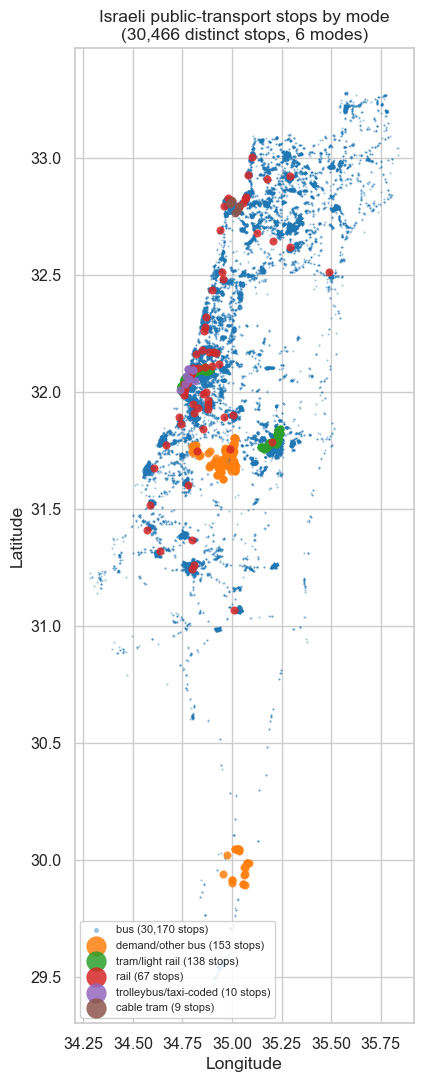

(mode, stop) rows without coordinates, excluded: 0
saved: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\14_multimodal_inventory\figures\mode_map.png


In [16]:
# --- Figure 3: stops coloured by mode ------------------------------------
map_df = stop_mode_geo.dropna(subset=['lat', 'lon']).copy()
dropped = len(stop_mode_geo) - len(map_df)
if map_df.empty:
    raise ValueError('No stop carries usable coordinates - check stops_clean.csv '
                     'from notebook 01_data_preparation.')

order = map_df.groupby('mode_label').size().sort_values(ascending=False).index.tolist()
palette = dict(zip(order, sns.color_palette('tab10', max(len(order), 3))))
rng = np.random.default_rng(SEED)

fig, ax = plt.subplots(figsize=(8, 11))
subsampled = []
for depth, mode in enumerate(order):
    sub = map_df[map_df['mode_label'] == mode]
    total = len(sub)
    if total > MAP_MAX_POINTS_PER_MODE:
        keep = rng.choice(total, MAP_MAX_POINTS_PER_MODE, replace=False)
        sub = sub.iloc[np.sort(keep)]
        subsampled.append(mode)
    size = 2 if total > 5_000 else (12 if total > 500 else 34)
    alpha = MAP_ALPHA if total > 5_000 else 0.85
    ax.scatter(sub['lon'], sub['lat'], s=size, alpha=alpha, linewidths=0,
               color=palette[mode], zorder=depth + 1,
               label=f'{mode} ({total:,} stops)')

ax.set_aspect(1 / np.cos(np.deg2rad(float(map_df['lat'].mean()))))
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Israeli public-transport stops by mode\n'
             '({:,} distinct stops, {} modes)'.format(map_df['stop_id'].nunique(),
                                                      len(order)))
ax.legend(loc='lower left', fontsize=8, markerscale=2.5, framealpha=0.9)
fig.tight_layout()
fig.savefig(FIGURES / 'mode_map.png', dpi=FIG_DPI)
plt.show()

print(f'(mode, stop) rows without coordinates, excluded: {dropped:,}')
if subsampled:
    print('subsampled for drawing only:', ', '.join(subsampled))
print('saved:', FIGURES / 'mode_map.png')

## 17. Why the modes differ structurally

The tables above are the what. This section is the why, because the structural differences aren't accidents of the data - they follow from how each transport mode is built and funded. (The route, trip and operator numbers cited here are the values this feed produces; the cells above recompute them, so if the feed is ever updated, trust the tables and not this prose.)

**Bus (`route_type = 3`) - a dense nationwide network.** 6,796 route records, 412,544 scheduled trips, 29 operators, and effectively the entire station inventory of the country. Buses run on roads that already exist, so adding a line costs a schedule and vehicles, not a right of way. The result is a graph with tens of thousands of nodes, average degree above 3, and real alternative routes in the metropolitan cores. But that same cheapness also produces long, thin, single-line branches out to small towns and rural areas, and those branches are trees - which is why the bus layer, though the most redundant mode in the country, still contributes thousands of articulation points. Its fragility is peripheral: many cuts, each isolating a small number of stations.

**Rail (`route_type = 2`) - a sparse graph close to a path.** 962 route records but only 1,188 scheduled trips and about 67 stations, all Israel Railways. Track is expensive and rail's geography is corridor geography: the network is essentially one north-south axis with a few branches. In graph terms this is close to a path, so average degree is around 2, most intermediate stations are articulation points and most segments are bridges. Rail has the highest per-station failure impact of any mode in the feed, which is exactly why notebook 11 could afford to brute-force simulate every single-station closure.

**Light rail / tram (`route_type = 0`) - tiny but very high frequency.** Only 8 route records, and yet 2,890 scheduled trips - more than double the entire heavy-rail plan - over a handful of stations, run by two operators on what the route names identify as the Jerusalem corridor (Hadassah Ein Kerem to Neve Yaakov). Structurally this is a path; operationally it's one of the busiest things in the feed. This is the clearest case where a network-size measure and a service-volume measure point in opposite directions, which is why `trips_per_edge` is in the detail table.

**Cable tram (`route_type = 5`) - four route records, about 3,006 trips.** Two Haifa operators appear under this code: the "Carmelit" funicular and a cable-car service between the Bay Central terminal and the University of Haifa. A handful of stations, very high trip counts, and a topology that is literally a line. Whether these belong in a study of a "public-transport network" at all is a judgment call; they're kept because silently dropping a mode is worse than reporting an odd one.

**Trolleybus (`route_type = 8`) - a mislabel, not a transport mode.** 8 route records and only 47 trips. The operators are Tel Aviv shared-taxi companies, so this code actually marks shared-taxi lines, not trolleybuses. Treating it as a separate transport mode would be an error; the label used here (`trolleybus/taxi-coded`) says so across every table.

**On-demand (`route_type = 715`) - 14 route records, 458 trips.** Rural on-demand services run by regional councils and two bus operators. These are buses in every physical sense; GTFS separates them because their service model is different. They contribute a small number of very sparse, mostly disconnected rural network fragments.

**The structural bottom line.** Redundancy tracks infrastructure cost - inversely. Modes that need a dedicated right of way (rail, light rail, cable car) are linear, minimal and therefore maximally vulnerable to cuts, and yet they carry a disproportionate share of the service. The mode that needs no dedicated infrastructure (bus) is the only one with real alternative routes - and it's also the only one whose failures are local rather than network-splitting. A robustness conclusion drawn from the merged graph containing all modes mixes these two very different regimes, and that's the central methodological argument for this notebook's existence.

**Caveats, stated plainly.**

* Edges are schedule adjacency, not track adjacency. An express service that skips intermediate stations creates a "shortcut" edge with no physical counterpart, which slightly inflates degree on rail and light rail.
* The weights are scheduled trips, not passengers. GTFS carries no demand data, so "important" here always means important in the supply network.
* Mode assignment is whatever the operator declared in `routes.txt`. As `route_type = 8` shows, that declaration isn't always meaningful: the six "modes" are really three transport realities - buses, rail on fixed track, and a few cable services in Haifa.
* The feed is a snapshot of one schedule window. The trip numbers are counts of scheduled trip records in that window, not trips per day.

## Conclusions

* The Israeli feed is one large network plus five small ones. The bus makes up the overwhelming majority of stations, segments and trips; every other mode is at least two orders of magnitude smaller on at least one axis. Any statement about "the Israeli transport network" computed on the merged graph is, numerically, a statement about the bus network.
* Size and service volume yield different rankings. Heavy rail has a hundred times more route records than light rail, but fewer than half its scheduled trips, and cable tram - four route records - runs more trips than heavy rail. Ranking the modes by network size and by service intensity produces nearly opposite orders, which is why both are reported.
* Fragility is inversely related to infrastructure cost. The fixed-track modes are near-path graphs: average degree close to 2, most stations articulation points, most segments bridges. The bus is the only mode with meaningful alternative routes, and yet in absolute terms it still contributes thousands of articulation points because its periphery is a forest of dead-end branches. These are two genuinely different failure regimes, and the merged graph averages between them.
* Two of the six "modes" are labeling artifacts. `route_type = 8` is used by shared-taxi operators, not trolleybuses, and `route_type = 715` is on-demand bus service. Neither is a separate physical network. They're reported because silently dropping them would be dishonest, but no structural conclusion should rest on them - 47 trips over 8 route records isn't a network, and any percentage computed on them is noise.
* The split reconciles with step 02. The union of the per-mode station and segment sets matches the full-network graph built in notebook 02, up to the documented and expected gaps (stations with no segment are nodes here but not there; a segment served by two modes appears in two counters). This is the evidence that the `trip -> route -> mode` join didn't silently misroute service, which is the one mistake this notebook could have made invisibly.
* What this frames. Notebook 15 takes the bus layer alone (the dense-network regime), 16 takes the light rail and minor modes (the path regime), 17 takes the stations where the modes meet - and the numbers here say in advance which of them is a large-graph problem that needs approximation and which can be solved exactly by brute force.